In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Text(0, 0.5, 'y')

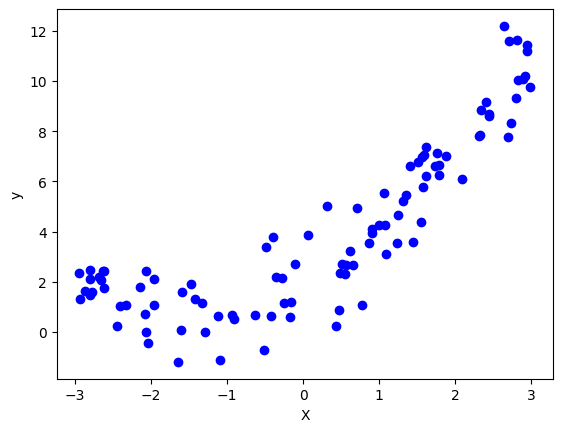

In [13]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)
# y = 0.5x^2 + 1.5x + 2 + noise(nhiễu) - np.random.randn(100, 1) ở đây dùng để
# sinh ra 100 giá trị mảng 100x1 từ phân phối chuẩn N(0,1)
# nhiễu ở đây là những thành phần ngẫu nhiên không thể đoán trước được
# nếu không có tất cả điểm sẽ nằm trên đường cong quá lý tưởng
# mô hình học quá dễ không có ý nghĩa thực tế
plt.scatter(X, y, color='blue')
plt.xlabel("X")
plt.ylabel("y")

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
## let's implemention simple linear regression model
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [16]:
regression_1.fit(X_train, y_train)

LinearRegression()

In [17]:
from sklearn.metrics import r2_score        
score = r2_score(y_test, regression_1.predict(X_test))
print(f"R^2 Score: {score}")

R^2 Score: 0.6965215516851643


Text(0, 0.5, 'y')

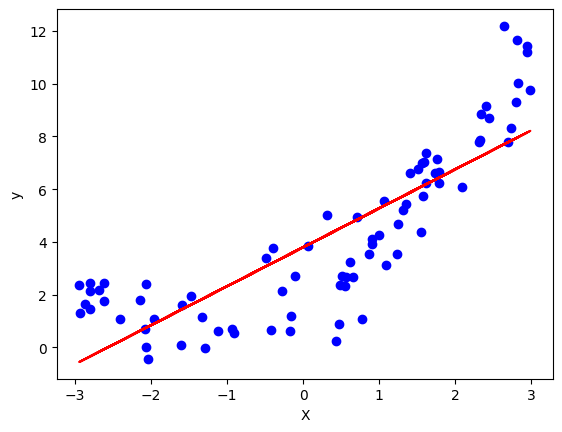

In [18]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train, regression_1.predict(X_train), color='red')
plt.xlabel("X")
plt.ylabel("y")


In [19]:
# let's implementation polynomial regression model
from sklearn.preprocessing import PolynomialFeatures

In [20]:
poly = PolynomialFeatures(degree=2,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [21]:
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(f"R^2 Score: {score}")

R^2 Score: 0.913767650077858


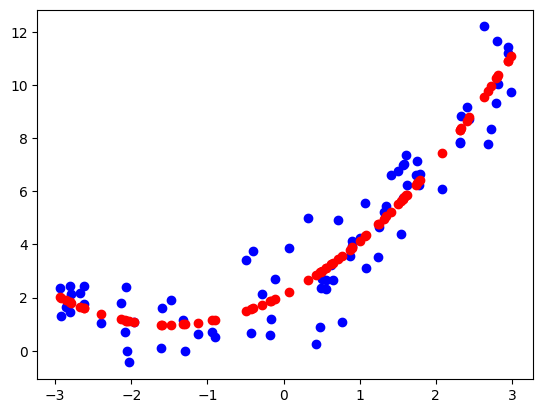

In [22]:
plt.scatter(X_train, y_train, color='blue')
plt.scatter(X_train, regression.predict(X_train_poly), color='red')

In [23]:
poly = PolynomialFeatures(degree=3,include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [24]:
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(f"R^2 Score: {score}")

R^2 Score: 0.917612605897477


In [25]:
# Prediction new data
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)

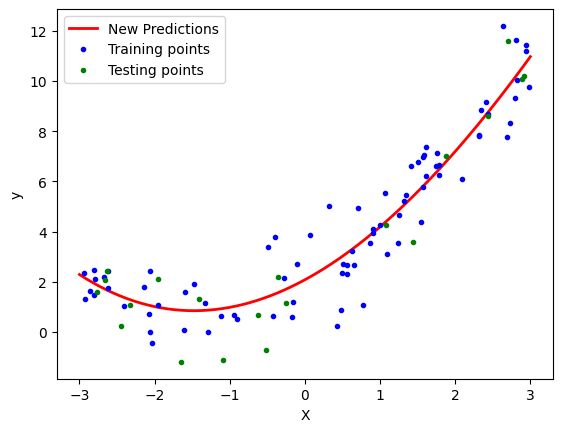

In [26]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label="New Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()


### Pipeline Concepts

In [27]:
from sklearn.pipeline import Pipeline


In [28]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    poly_features=PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features", poly_features), # biến đổi đầu vào thành đặc trưng đa thức
        ("lin_reg", lin_reg) # áp dụng hồi quy tuyến tính lên các đặc trưng đa thức
    ])
    poly_regression.fit(X_train, y_train)
    y_pred_new=poly_regression.predict(X_new)
    #Plotting prediction line
    plt.plot(X_new, y_pred_new, 'r', label="Degree " + str(degree), linewidth=3)
    plt.plot(X_train, y_train, 'b.', linewidth=3)
    plt.plot(X_test, y_test, 'g.', linewidth=3)
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

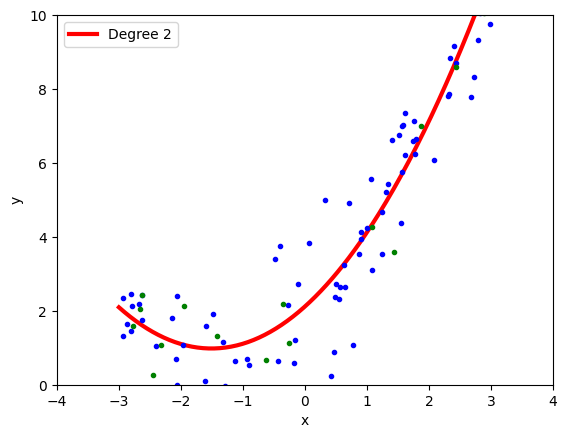

In [ ]:
poly_regression(2)
# Nếu degree cao gây ra overfitting - mô hình cố gắng đi qua hết tất cả các điểm dữ liệu huấn luyện
# Điều này làm mô hình phức tạp hơn và có thể dẫn đến hiệu suất kém trên dữ liệu mới